In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the dataset (make sure CSV is in the same folder as your notebook)
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# Preview first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape of dataset: (9994, 21)

Column Names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer N

In [5]:
# Drop unnecessary columns
df.drop(columns=['Row ID', 'Postal Code'], inplace=True)

# Convert Order Date and Ship Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract Year and Month from Order Date
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')

print("Data cleaned successfully!")
print("Shape after cleaning:", df.shape)
df.head()

Data cleaned successfully!
Shape after cleaning: (9994, 22)


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Nov
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Nov
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Jun
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Oct
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Oct


In [6]:
print("=== KEY METRICS ===")
print(f"Total Sales     : ${df['Sales'].sum():,.2f}")
print(f"Total Profit    : ${df['Profit'].sum():,.2f}")
print(f"Total Orders    : {df['Order ID'].nunique()}")
print(f"Total Customers : {df['Customer ID'].nunique()}")
print(f"Profit Margin   : {(df['Profit'].sum()/df['Sales'].sum())*100:.2f}%")

=== KEY METRICS ===
Total Sales     : $2,297,200.86
Total Profit    : $286,397.02
Total Orders    : 5009
Total Customers : 793
Profit Margin   : 12.47%


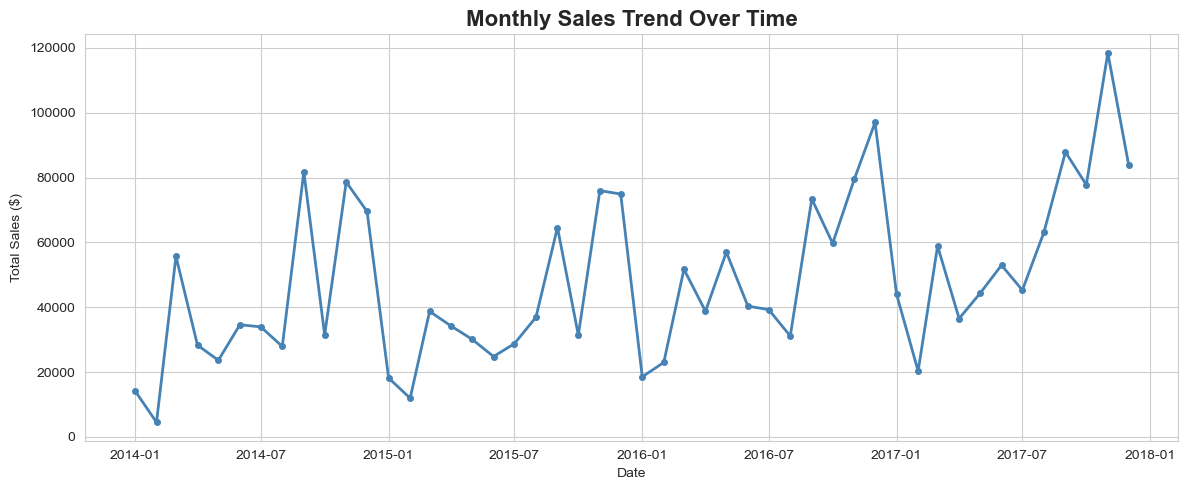

In [7]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(DAY=1))

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Sales Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150)
plt.show()

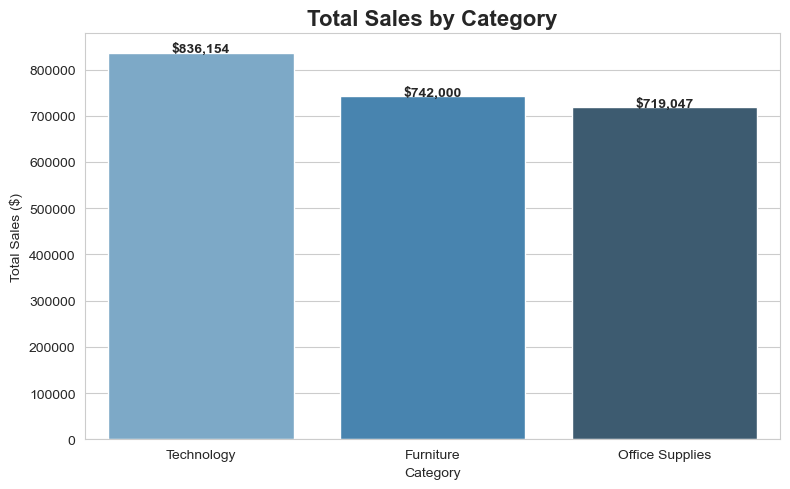

In [9]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, 
            hue=category_sales.index, palette='Blues_d', legend=False)
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
for i, v in enumerate(category_sales.values):
    plt.text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('sales_by_category.png', dpi=150)
plt.show()

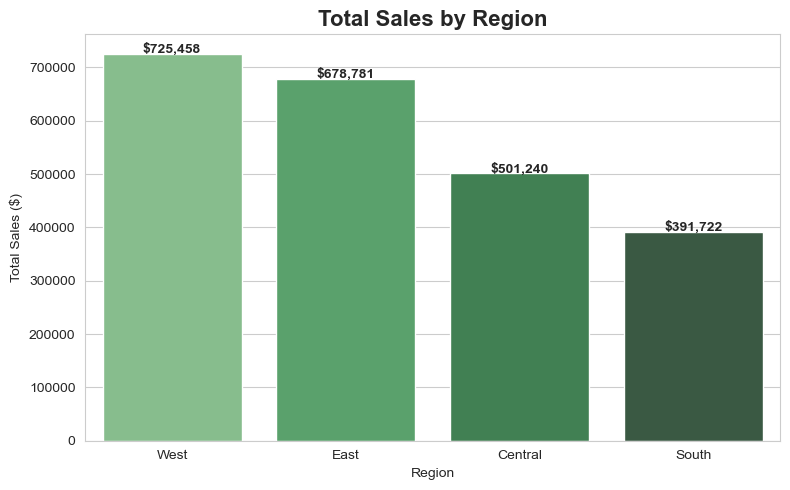

In [10]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values,
            hue=region_sales.index, palette='Greens_d', legend=False)
plt.title('Total Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
for i, v in enumerate(region_sales.values):
    plt.text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('sales_by_region.png', dpi=150)
plt.show()

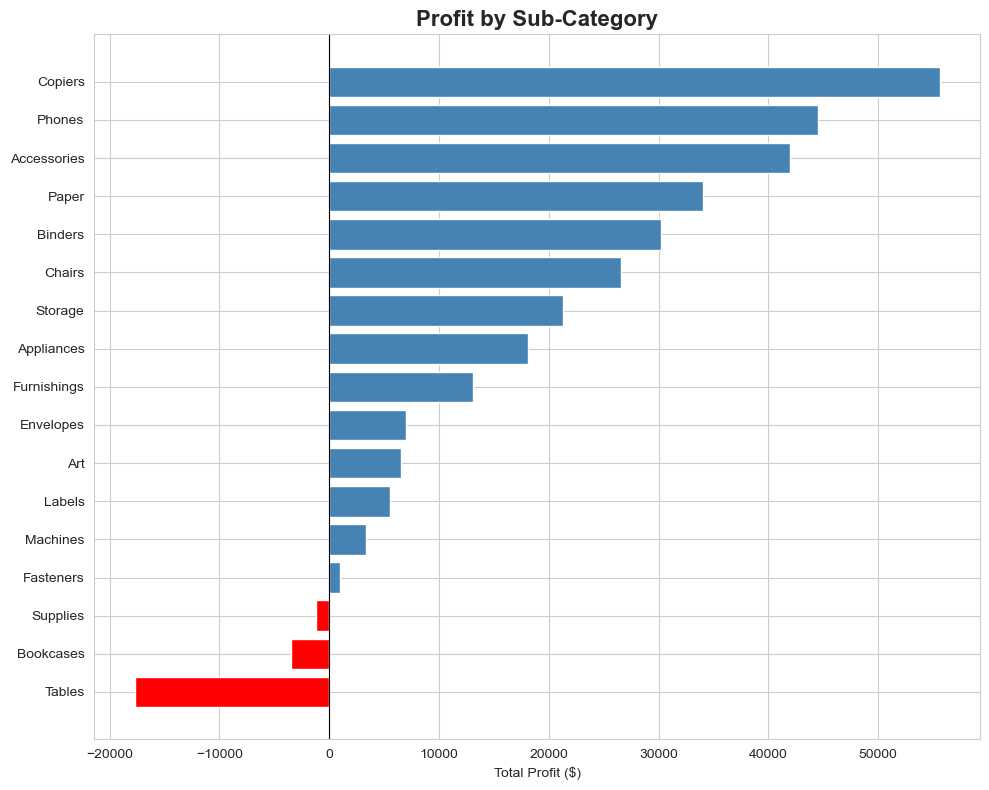

In [11]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

colors = ['red' if x < 0 else 'steelblue' for x in subcategory_profit.values]

plt.figure(figsize=(10, 8))
plt.barh(subcategory_profit.index, subcategory_profit.values, color=colors)
plt.title('Profit by Sub-Category', fontsize=16, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('profit_by_subcategory.png', dpi=150)
plt.show()

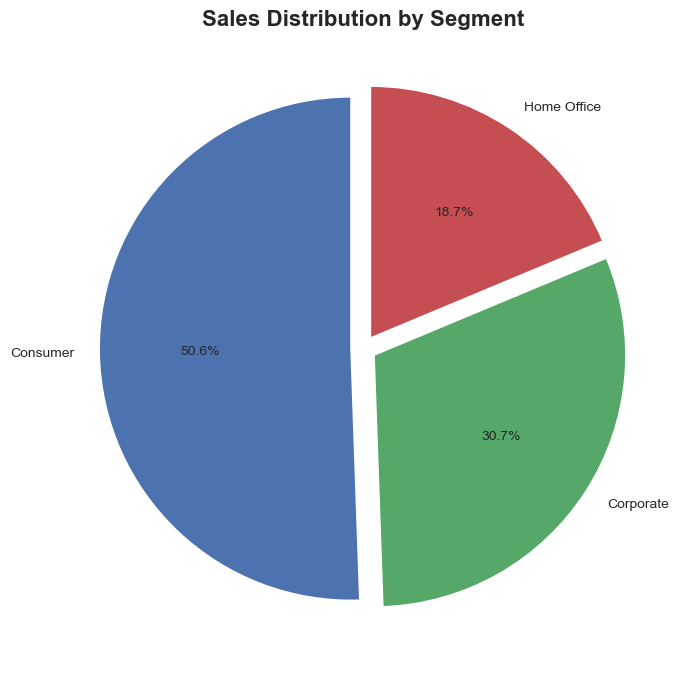

In [12]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7, 7))
plt.pie(segment_sales.values, labels=segment_sales.index,
        autopct='%1.1f%%', colors=['#4C72B0','#55A868','#C44E52'],
        startangle=90, explode=[0.05]*3)
plt.title('Sales Distribution by Segment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sales_by_segment.png', dpi=150)
plt.show()

In [13]:
print("=" * 50)
print("        KEY BUSINESS INSIGHTS")
print("=" * 50)

print("\n1. SALES TREND:")
print(f"   Best year: {df.groupby('Year')['Sales'].sum().idxmax()}")
print(f"   Best month overall: {df.groupby('Month Name')['Sales'].sum().idxmax()}")

print("\n2. CATEGORY PERFORMANCE:")
best_cat = df.groupby('Category')['Sales'].sum().idxmax()
print(f"   Top category by sales: {best_cat}")

print("\n3. REGIONAL PERFORMANCE:")
best_region = df.groupby('Region')['Sales'].sum().idxmax()
worst_region = df.groupby('Region')['Sales'].sum().idxmin()
print(f"   Best region : {best_region}")
print(f"   Worst region: {worst_region}")

print("\n4. PROFITABILITY:")
loss_subcats = df.groupby('Sub-Category')['Profit'].sum()
loss_subcats = loss_subcats[loss_subcats < 0].index.tolist()
print(f"   Loss-making sub-categories: {loss_subcats}")

print("\n5. DISCOUNT IMPACT:")
print(f"   Average discount: {df['Discount'].mean()*100:.1f}%")
print("=" * 50)

        KEY BUSINESS INSIGHTS

1. SALES TREND:
   Best year: 2017
   Best month overall: Nov

2. CATEGORY PERFORMANCE:
   Top category by sales: Technology

3. REGIONAL PERFORMANCE:
   Best region : West
   Worst region: South

4. PROFITABILITY:
   Loss-making sub-categories: ['Bookcases', 'Supplies', 'Tables']

5. DISCOUNT IMPACT:
   Average discount: 15.6%
